# SAE reconstruction as activation denoising

Pipeline: stream Gemma hidden activations -> Gemma Scope SAE encoder -> latent z -> SAE decoder -> reconstructed activations.

The goal is to test whether SAE reconstruction reduces heavy tails, anisotropy, and high-variance directions while preserving the activation distribution closely enough for downstream flow matching / transport models.


In [ ]:
from __future__ import annotations

import gc
import json
import os
import sys
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 160)

benchmark_root = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "Steering" / "post_process").exists():
        benchmark_root = candidate
        break
if benchmark_root is None:
    raise RuntimeError("Could not locate the Benchmark workspace root")
if str(benchmark_root) not in sys.path:
    sys.path.insert(0, str(benchmark_root))

from IPython.display import display
from sae_lens import SAE

from Steering.post_process.activation_stream import FineWebConfig, iter_stream_texts
from Steering.post_process.fd_utils import compute_fd, compute_fd_1d
from Steering.post_process.train_stream import StreamTrainConfig, _load_model_and_tokenizer


def parse_torch_dtype(name: str) -> torch.dtype:
    mapping = {
        "float16": torch.float16,
        "bfloat16": torch.bfloat16,
        "float32": torch.float32,
    }
    if name not in mapping:
        raise ValueError(f"Unsupported dtype: {name}")
    return mapping[name]


CONFIG = {
    # Gemma Scope canonical SAEs are trained for Gemma 2 2B residual streams.
    "model_name": "google/gemma-2-2b-it",
    "layer": 14,
    "hf_hidden_state_index": 15,  # HF hidden_states[0] is embeddings, so layer 14 resid_post is index 15.
    "sae_release": "gemma-scope-2b-pt-res-canonical",
    "sae_id": "layer_14/width_16k/canonical",
    "device": "cuda:0" if torch.cuda.is_available() else "cpu",
    "model_dtype": "bfloat16",
    "sae_device": "cuda:0" if torch.cuda.is_available() else "cpu",
    "num_vectors": 50_000,
    "fd_eval_vectors": 20_000,
    "stats_eval_vectors": 20_000,
    "max_length": 1024,
    "forward_batch_size": 1,
    "drop_bos": True,
    "reconstruct_batch_size": 512,
    "seed": 42,
    "source": {
        "dataset_name": "HuggingFaceFW/fineweb",
        "dataset_config": "sample-10BT",
        "split": "train",
        "text_field": "text",
    },
}

NOTEBOOK_DIR = benchmark_root / "Steering" / "post_process"
OUTPUT_DIR = NOTEBOOK_DIR / "sae_analysis_artifacts"
CACHE_DIR = OUTPUT_DIR / "cache"
FIG_DIR = OUTPUT_DIR / "figures"
for directory in [OUTPUT_DIR, CACHE_DIR, FIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])

print(f"Benchmark root: {benchmark_root}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"Device: {CONFIG['device']}")
print(f"SAE: {CONFIG['sae_release']} :: {CONFIG['sae_id']}")


Benchmark root: /mnt/disk2/aiotlab/hoplt/Benchmark
Output directory: /mnt/disk2/aiotlab/hoplt/Benchmark/Steering/post_process/sae_analysis_artifacts
Device: cuda:0
SAE: gemma-scope-2b-pt-res-canonical :: layer_14/width_16k/canonical


## 1. Load Gemma and Gemma Scope SAE

The hidden-state index is set to `layer + 1` because HuggingFace `hidden_states[0]` is the embedding output. This aligns Gemma Scope `layer_14` with the residual stream after transformer layer 14.


In [2]:
model_dtype = parse_torch_dtype(CONFIG["model_dtype"])

load_cfg = StreamTrainConfig(
    model_name=CONFIG["model_name"],
    device=CONFIG["device"],
    torch_dtype=CONFIG["model_dtype"],
)
hf_model, hf_tokenizer = _load_model_and_tokenizer(load_cfg)

print("Loading SAE...")
sae, sae_cfg, sparsity = SAE.from_pretrained(
    CONFIG["sae_release"],
    CONFIG["sae_id"],
    device=CONFIG["sae_device"],
)
sae = sae.to(device=CONFIG["sae_device"], dtype=model_dtype)
sae.eval()
sae.requires_grad_(False)


def sae_encode(sae_model, x: torch.Tensor) -> torch.Tensor:
    """Version-tolerant SAE encoder helper for SAE Lens variants."""
    if hasattr(sae_model, "encode"):
        return sae_model.encode(x)

    architecture = str(getattr(getattr(sae_model, "cfg", None), "architecture", "")).lower()
    if "jumprelu" in architecture and hasattr(sae_model, "encode_jumprelu"):
        return sae_model.encode_jumprelu(x)
    if "gated" in architecture and hasattr(sae_model, "encode_gated"):
        return sae_model.encode_gated(x)
    if hasattr(sae_model, "encode_standard"):
        return sae_model.encode_standard(x)
    if hasattr(sae_model, "encode_jumprelu"):
        return sae_model.encode_jumprelu(x)
    raise AttributeError("Could not find a supported encoder method on the SAE object")


sae_d_in = int(getattr(getattr(sae, "cfg", None), "d_in", getattr(sae, "d_in", 0)))
sae_d_sae = int(getattr(getattr(sae, "cfg", None), "d_sae", getattr(sae, "d_sae", 0)))
model_d = int(getattr(hf_model.config, "hidden_size", 0))

assert model_d == sae_d_in, f"Model hidden size {model_d} != SAE d_in {sae_d_in}"
assert CONFIG["hf_hidden_state_index"] <= hf_model.config.num_hidden_layers, (
    f"hidden_state_index={CONFIG['hf_hidden_state_index']} is out of range for "
    f"{hf_model.config.num_hidden_layers} transformer layers"
)

print(f"Model hidden size: {model_d}")
print(f"SAE d_in: {sae_d_in}")
print(f"SAE d_sae: {sae_d_sae}")
print(f"SAE cfg architecture: {getattr(getattr(sae, 'cfg', None), 'architecture', 'unknown')}")


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading SAE...
Model hidden size: 2304
SAE d_in: 2304
SAE d_sae: 16384
SAE cfg architecture: jumprelu


## 2. Stream hidden activations

This mirrors the streaming pattern in `gemma_demo.ipynb`, but uses the `layer + 1` HF hidden-state index for Gemma Scope residual-post alignment. Activations are cached to avoid repeated FineWeb/model passes.


In [3]:
@torch.no_grad()
def stream_hidden_activations(
    hf_model,
    hf_tokenizer,
    *,
    hidden_state_index: int,
    num_vectors: int,
    source: dict,
    forward_batch_size: int,
    max_length: int,
    drop_bos: bool,
) -> torch.Tensor:
    cfg = FineWebConfig(
        dataset_name=source["dataset_name"],
        dataset_config=source["dataset_config"],
        split=source["split"],
        text_field=source["text_field"],
        streaming=True,
    )
    text_stream = iter_stream_texts(cfg)
    chunks: list[torch.Tensor] = []
    total = 0

    pbar = tqdm(total=num_vectors, desc="Stream activations")
    while total < num_vectors:
        batch_texts = []
        for _ in range(forward_batch_size):
            try:
                batch_texts.append(next(text_stream))
            except StopIteration:
                break
        if not batch_texts:
            break

        inputs = hf_tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        )
        inputs = {k: v.to(hf_model.device) for k, v in inputs.items()}
        outputs = hf_model(**inputs, output_hidden_states=True, use_cache=False)
        hidden = outputs.hidden_states[hidden_state_index].detach().cpu().float()
        mask = inputs["attention_mask"].detach().cpu().bool()

        valid_docs = []
        for doc_acts, doc_mask in zip(hidden, mask):
            doc_acts = doc_acts[doc_mask]
            if drop_bos and doc_acts.shape[0] > 1:
                doc_acts = doc_acts[1:]
            if doc_acts.shape[0] > 0:
                valid_docs.append(doc_acts)
        if not valid_docs:
            continue

        valid = torch.cat(valid_docs, dim=0)
        remaining = num_vectors - total
        valid = valid[:remaining]
        chunks.append(valid)
        total += valid.shape[0]
        pbar.update(valid.shape[0])

        del outputs, hidden, inputs, valid
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    pbar.close()
    if not chunks:
        raise RuntimeError("No activations were collected")
    return torch.cat(chunks, dim=0)[:num_vectors]


activation_cache_path = CACHE_DIR / (
    f"acts_{CONFIG['model_name'].split('/')[-1]}_layer{CONFIG['layer']}_"
    f"hfidx{CONFIG['hf_hidden_state_index']}_n{CONFIG['num_vectors']}.pt"
)

if activation_cache_path.exists():
    print(f"Loading cached activations from {activation_cache_path}")
    acts = torch.load(activation_cache_path, map_location="cpu")["activations"].float()
else:
    acts = stream_hidden_activations(
        hf_model,
        hf_tokenizer,
        hidden_state_index=CONFIG["hf_hidden_state_index"],
        num_vectors=CONFIG["num_vectors"],
        source=CONFIG["source"],
        forward_batch_size=CONFIG["forward_batch_size"],
        max_length=CONFIG["max_length"],
        drop_bos=CONFIG["drop_bos"],
    )
    torch.save({"activations": acts.to(torch.bfloat16), "config": CONFIG}, activation_cache_path)
    print(f"Saved activations to {activation_cache_path}")

assert acts.ndim == 2 and acts.shape[-1] == sae_d_in, tuple(acts.shape)
print(f"Activation shape: {tuple(acts.shape)}")
print(f"Activation dtype: {acts.dtype}")


Loading cached activations from /mnt/disk2/aiotlab/hoplt/Benchmark/Steering/post_process/sae_analysis_artifacts/cache/acts_gemma-2-2b-it_layer14_hfidx15_n50000.pt
Activation shape: (50000, 2304)
Activation dtype: torch.float32


## 3. SAE encode/decode reconstruction

This cell performs `act -> encoder -> z -> decoder -> reconstructed act` in chunks, while also recording sparse latent usage statistics.


In [4]:
@torch.no_grad()
def reconstruct_with_sae(
    acts: torch.Tensor,
    sae_model,
    *,
    batch_size: int,
    dtype: torch.dtype,
) -> tuple[torch.Tensor, pd.DataFrame]:
    sae_device = next(sae_model.parameters()).device
    recon_chunks: list[torch.Tensor] = []
    latent_rows: list[dict] = []

    for start in tqdm(range(0, acts.shape[0], batch_size), desc="SAE reconstruct"):
        chunk = acts[start : start + batch_size].to(device=sae_device, dtype=dtype)
        z = sae_encode(sae_model, chunk)
        recon = sae_model.decode(z)
        recon_chunks.append(recon.detach().cpu().float())

        z_cpu = z.detach().float().cpu()
        active = z_cpu > 0
        latent_rows.append(
            {
                "start": start,
                "end": start + chunk.shape[0],
                "batch_size": chunk.shape[0],
                "l0_mean": active.sum(dim=-1).float().mean().item(),
                "l0_median": active.sum(dim=-1).float().median().item(),
                "density_mean": active.float().mean().item(),
                "l1_mean": z_cpu.abs().sum(dim=-1).mean().item(),
                "z_abs_mean": z_cpu.abs().mean().item(),
                "z_max": z_cpu.max().item(),
            }
        )

        del chunk, z, recon, z_cpu, active
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return torch.cat(recon_chunks, dim=0), pd.DataFrame(latent_rows)


recon_cache_path = CACHE_DIR / (
    f"sae_recon_{CONFIG['model_name'].split('/')[-1]}_layer{CONFIG['layer']}_"
    f"{CONFIG['sae_id'].replace('/', '-')}_n{CONFIG['num_vectors']}.pt"
)

if recon_cache_path.exists():
    print(f"Loading cached SAE reconstruction from {recon_cache_path}")
    payload = torch.load(recon_cache_path, map_location="cpu")
    recon_acts = payload["recon_acts"].float()
    latent_batch_stats = pd.DataFrame(payload.get("latent_batch_stats", []))
else:
    recon_acts, latent_batch_stats = reconstruct_with_sae(
        acts,
        sae,
        batch_size=CONFIG["reconstruct_batch_size"],
        dtype=model_dtype,
    )
    torch.save(
        {
            "acts_shape": tuple(acts.shape),
            "recon_acts": recon_acts.to(torch.bfloat16),
            "latent_batch_stats": latent_batch_stats.to_dict(orient="records"),
            "config": CONFIG,
        },
        recon_cache_path,
    )
    print(f"Saved SAE reconstruction to {recon_cache_path}")

assert recon_acts.shape == acts.shape, (tuple(recon_acts.shape), tuple(acts.shape))
latent_summary = latent_batch_stats.drop(columns=["start", "end"], errors="ignore").mean(numeric_only=True).to_frame("mean").T
print(f"Reconstruction shape: {tuple(recon_acts.shape)}")
display(latent_summary.round(6))


Loading cached SAE reconstruction from /mnt/disk2/aiotlab/hoplt/Benchmark/Steering/post_process/sae_analysis_artifacts/cache/sae_recon_gemma-2-2b-it_layer14_layer_14-width_16k-canonical_n50000.pt
Reconstruction shape: (50000, 2304)


,batch_size,l0_mean,l0_median,density_mean,l1_mean,z_abs_mean,z_max
mean,510.204082,106.297145,103.887755,0.006488,846.391485,0.05166,290.556122


## 4. FD and reconstruction metrics

FD is computed between original activations and SAE reconstructions on a configurable subset. The diagonal/per-dimension FD table is useful for identifying dimensions where the SAE changes the distribution most.


In [5]:
def reconstruction_metrics(x: torch.Tensor, y: torch.Tensor) -> dict:
    x = x.float()
    y = y.float()
    residual = y - x
    mse = residual.pow(2).mean().item()
    rmse = float(np.sqrt(mse))
    mae = residual.abs().mean().item()
    rel_l2 = (residual.norm(dim=-1) / x.norm(dim=-1).clamp_min(1e-12)).mean().item()
    cosine = torch.nn.functional.cosine_similarity(x, y, dim=-1).mean().item()
    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "relative_l2_mean": rel_l2,
        "cosine_mean": cosine,
    }


n_fd = min(CONFIG["fd_eval_vectors"], acts.shape[0], recon_acts.shape[0])
act_eval = acts[:n_fd].float()
recon_eval = recon_acts[:n_fd].float()

print(f"Computing full multivariate FD on {n_fd} vectors x {act_eval.shape[-1]} dims...")
fd, fd_ratio = compute_fd(act_eval, recon_eval, seed=CONFIG["seed"])
fd_1d = compute_fd_1d(act_eval, recon_eval)
fd_diag = float(np.sum(fd_1d["fd_1d"]))

metrics = reconstruction_metrics(act_eval, recon_eval)
metrics.update(
    {
        "fd_full": fd,
        "fd_ratio_vs_noise": fd_ratio,
        "fd_diagonal_sum": fd_diag,
        "fd_eval_vectors": n_fd,
        "d_model": act_eval.shape[-1],
    }
)
metrics_df = pd.DataFrame([metrics])
display(metrics_df.T.rename(columns={0: "value"}))

fd_1d_df = pd.DataFrame(
    {
        "dim": np.arange(len(fd_1d["fd_1d"])),
        "mu_act": fd_1d["mu_ref"],
        "mu_recon": fd_1d["mu_gen"],
        "sigma_act": fd_1d["sigma_ref"],
        "sigma_recon": fd_1d["sigma_gen"],
        "fd_1d": fd_1d["fd_1d"],
        "mean_delta": fd_1d["mu_gen"] - fd_1d["mu_ref"],
        "sigma_delta": fd_1d["sigma_gen"] - fd_1d["sigma_ref"],
    }
).sort_values("fd_1d", ascending=False).reset_index(drop=True)

print("Top dimensions changed by SAE reconstruction:")
display(fd_1d_df.head(15).round(6))


Computing full multivariate FD on 20000 vectors x 2304 dims...


,value
mse,3.020317
rmse,1.737906
mae,1.363427
relative_l2_mean,0.407652
cosine_mean,0.912233
fd_full,2444.846852
fd_ratio_vs_noise,0.072511
fd_diagonal_sum,1111.945959
fd_eval_vectors,20000.000000
d_model,2304.000000


Top dimensions changed by SAE reconstruction:


,dim,mu_act,mu_recon,sigma_act,sigma_recon,fd_1d,mean_delta,sigma_delta
0,1824,11.559039,8.601349,14.877988,14.531726,8.867828,-2.957690,-0.346261
1,1234,-10.344833,-13.212495,3.310893,2.658313,8.649349,-2.867662,-0.652580
2,1405,9.329371,6.495136,10.862635,10.675637,8.067856,-2.834235,-0.186998
3,714,-11.300816,-8.836655,13.130839,12.874458,6.137821,2.464161,-0.256382
4,1026,-3.628450,-1.178759,8.570855,8.237987,6.111790,2.449692,-0.332869
5,557,3.739768,1.823314,9.922383,9.504471,3.847448,-1.916454,-0.417913
6,987,-5.549578,-3.646552,12.413809,12.075617,3.735884,1.903027,-0.338192
7,1170,0.089669,0.283952,16.216373,14.383396,3.397548,0.194283,-1.832976
8,1651,-4.057019,-2.314787,8.884678,8.643427,3.093572,1.742231,-0.241250
9,2213,-3.636001,-1.933302,6.578197,6.251417,3.005969,1.702699,-0.326780


## 5. Heavy-tail, variance, and anisotropy diagnostics

This compares original vs reconstructed activation distributions by per-dimension moments and covariance spectrum. Lower excess kurtosis, lower tail ratios, and a less concentrated covariance spectrum would support the denoising / manifold regularization hypothesis.


In [6]:
def summarize_distribution(x: torch.Tensor, name: str) -> tuple[pd.DataFrame, dict, np.ndarray]:
    x = x.float()
    mean = x.mean(dim=0)
    centered = x - mean
    var = centered.pow(2).mean(dim=0).clamp_min(1e-12)
    std = var.sqrt()
    skew = centered.pow(3).mean(dim=0) / std.pow(3).clamp_min(1e-12)
    kurtosis = centered.pow(4).mean(dim=0) / var.pow(2).clamp_min(1e-12) - 3.0
    abs_x = x.abs()
    q95_abs = torch.quantile(abs_x, 0.95, dim=0)
    q99_abs = torch.quantile(abs_x, 0.99, dim=0)
    max_abs = abs_x.max(dim=0).values
    tail_ratio = max_abs / abs_x.mean(dim=0).clamp_min(1e-12)

    dim_df = pd.DataFrame(
        {
            "dim": np.arange(x.shape[-1]),
            f"{name}_mean": mean.cpu().numpy(),
            f"{name}_var": var.cpu().numpy(),
            f"{name}_std": std.cpu().numpy(),
            f"{name}_skew": skew.cpu().numpy(),
            f"{name}_excess_kurtosis": kurtosis.cpu().numpy(),
            f"{name}_q95_abs": q95_abs.cpu().numpy(),
            f"{name}_q99_abs": q99_abs.cpu().numpy(),
            f"{name}_max_abs": max_abs.cpu().numpy(),
            f"{name}_tail_ratio": tail_ratio.cpu().numpy(),
        }
    )

    cov = (centered.T @ centered) / max(x.shape[0] - 1, 1)
    eigvals = torch.linalg.eigvalsh(cov.cpu()).clamp_min(0).flip(0).numpy()
    eig_sum = float(eigvals.sum() + 1e-12)
    global_stats = {
        "name": name,
        "n": int(x.shape[0]),
        "d": int(x.shape[1]),
        "mean_var": float(var.mean().item()),
        "median_var": float(var.median().item()),
        "max_var": float(var.max().item()),
        "mean_abs_mean": float(mean.abs().mean().item()),
        "mean_excess_kurtosis": float(kurtosis.mean().item()),
        "median_excess_kurtosis": float(kurtosis.median().item()),
        "max_excess_kurtosis": float(kurtosis.max().item()),
        "mean_tail_ratio": float(tail_ratio.mean().item()),
        "median_tail_ratio": float(tail_ratio.median().item()),
        "max_tail_ratio": float(tail_ratio.max().item()),
        "cov_top1_energy_pct": float(100.0 * eigvals[0] / eig_sum),
        "cov_top10_energy_pct": float(100.0 * eigvals[:10].sum() / eig_sum),
        "cov_top100_energy_pct": float(100.0 * eigvals[:100].sum() / eig_sum),
        "participation_ratio": float((eigvals.sum() ** 2) / ((eigvals ** 2).sum() + 1e-12)),
    }
    return dim_df, global_stats, eigvals


n_stats = min(CONFIG["stats_eval_vectors"], acts.shape[0], recon_acts.shape[0])
act_stats_df, act_global, act_eigvals = summarize_distribution(acts[:n_stats], "act")
recon_stats_df, recon_global, recon_eigvals = summarize_distribution(recon_acts[:n_stats], "recon")

stats_df = act_stats_df.merge(recon_stats_df, on="dim")
stats_df["var_delta"] = stats_df["recon_var"] - stats_df["act_var"]
stats_df["kurtosis_delta"] = stats_df["recon_excess_kurtosis"] - stats_df["act_excess_kurtosis"]
stats_df["tail_ratio_delta"] = stats_df["recon_tail_ratio"] - stats_df["act_tail_ratio"]
stats_df["abs_mean_delta"] = (stats_df["recon_mean"] - stats_df["act_mean"]).abs()

global_df = pd.DataFrame([act_global, recon_global])
comparison = (global_df.set_index("name").loc["recon"] - global_df.set_index("name").loc["act"]).to_frame("recon_minus_act").T

display(global_df.round(6))
print("Reconstruction minus original distribution stats:")
display(comparison.round(6))

print("Top original variance dimensions:")
display(stats_df.sort_values("act_var", ascending=False).head(15).round(6))

print("Top dimensions where SAE reduced variance most:")
display(stats_df.sort_values("var_delta", ascending=True).head(15).round(6))


,name,n,d,mean_var,median_var,max_var,mean_abs_mean,mean_excess_kurtosis,median_excess_kurtosis,max_excess_kurtosis,mean_tail_ratio,median_tail_ratio,max_tail_ratio,cov_top1_energy_pct,cov_top10_energy_pct,cov_top100_energy_pct,participation_ratio
0,act,20000,2304,11.105164,6.860909,1069.218872,0.651489,0.426690,0.206371,383.936340,5.792696,5.689266,110.450653,5.527005,23.127983,47.999243,119.765569
1,recon,20000,2304,8.345905,4.109453,1058.645142,0.490126,0.594409,0.316688,396.704163,6.120160,5.961433,109.388344,7.354230,29.440912,57.928995,73.969120


Reconstruction minus original distribution stats:


,n,d,mean_var,median_var,max_var,mean_abs_mean,mean_excess_kurtosis,median_excess_kurtosis,max_excess_kurtosis,mean_tail_ratio,median_tail_ratio,max_tail_ratio,cov_top1_energy_pct,cov_top10_energy_pct,cov_top100_energy_pct,participation_ratio
recon_minus_act,0.0,0.0,-2.759258,-2.751455,-10.57373,-0.161363,0.167719,0.110317,12.767822,0.327464,0.272167,-1.062309,1.827224,6.312929,9.929751,-45.796449


Top original variance dimensions:


,dim,act_mean,act_var,act_std,act_skew,act_excess_kurtosis,act_q95_abs,act_q99_abs,act_max_abs,act_tail_ratio,recon_mean,recon_var,recon_std,recon_skew,recon_excess_kurtosis,recon_q95_abs,recon_q99_abs,recon_max_abs,recon_tail_ratio,var_delta,kurtosis_delta,tail_ratio_delta,abs_mean_delta
334,334,109.320427,1069.218872,32.698914,5.003630,65.608299,150.000000,168.000000,600.00,5.488416,109.040077,1058.645142,32.536827,4.979684,65.307343,150.000000,168.000000,600.00,5.502531,-10.573730,-0.300957,0.014115,0.280350
1068,1068,23.164742,628.533386,25.070568,-0.002684,-0.893575,62.750000,71.500000,96.50,3.477356,23.712122,641.801758,25.333805,-0.049370,-0.855969,63.250000,71.500000,97.00,3.423840,13.268372,0.037606,-0.053515,0.547380
1046,1046,16.263512,517.558838,22.749920,-0.202651,-0.471820,51.750000,62.750000,84.00,3.585978,15.247350,504.740295,22.466427,-0.180628,-0.461352,50.500000,61.500000,82.50,3.639696,-12.818542,0.010468,0.053717,1.016162
1570,1570,30.872440,353.208557,18.793844,-0.085520,-0.317686,61.750000,71.500000,89.50,2.826041,30.687349,379.143402,19.471605,-0.199545,0.113607,62.500000,72.000000,93.50,2.946217,25.934843,0.431293,0.120176,0.185091
113,113,-8.630164,269.875427,16.427885,-0.059314,-0.032640,36.000000,47.750000,78.50,5.289922,-7.751818,261.698181,16.177088,-0.057903,0.009634,34.750000,46.500000,80.50,5.615640,-8.177246,0.042274,0.325718,0.878346
1170,1170,0.089669,262.970764,16.216373,-19.041019,383.936340,7.000000,10.687500,380.00,110.450653,0.283952,206.882095,14.383396,-19.228985,396.704163,6.843750,10.750000,352.00,109.388344,-56.088669,12.767822,-1.062309,0.194283
1546,1546,-12.218694,247.722519,15.739203,0.129984,0.042030,38.000000,47.500000,63.00,3.865645,-10.994337,251.004974,15.843137,0.175715,0.107861,36.750000,46.250000,67.00,4.263380,3.282456,0.065831,0.397735,1.224357
784,784,3.199952,240.288223,15.501233,-0.042448,0.159665,31.000000,41.250000,65.00,5.180851,2.550084,241.039749,15.525455,-0.031595,0.156187,30.750000,41.000000,65.50,5.255378,0.751526,-0.003478,0.074527,0.649868
1824,1824,11.559040,221.354523,14.877988,-0.106953,0.131950,35.750000,46.000000,66.00,4.297457,8.601350,211.171051,14.531726,-0.106207,0.147988,32.500000,42.250000,58.75,4.321829,-10.183472,0.016038,0.024372,2.957690
948,948,-5.765194,195.708252,13.989576,0.213163,0.277411,29.875000,38.000000,58.25,4.820839,-6.079337,196.428986,14.015312,0.192565,0.276376,30.131104,38.500000,59.25,4.860583,0.720734,-0.001035,0.039744,0.314143


Top dimensions where SAE reduced variance most:


,dim,act_mean,act_var,act_std,act_skew,act_excess_kurtosis,act_q95_abs,act_q99_abs,act_max_abs,act_tail_ratio,recon_mean,recon_var,recon_std,recon_skew,recon_excess_kurtosis,recon_q95_abs,recon_q99_abs,recon_max_abs,recon_tail_ratio,var_delta,kurtosis_delta,tail_ratio_delta,abs_mean_delta
1170,1170,0.089669,262.970764,16.216373,-19.041019,383.936340,7.000,10.687500,380.00,110.450653,0.283952,206.882095,14.383396,-19.228985,396.704163,6.843750,10.750000,352.00,109.388344,-56.088669,12.767822,-1.062309,0.194283
1046,1046,16.263512,517.558838,22.749920,-0.202651,-0.471820,51.750,62.750000,84.00,3.585978,15.247350,504.740295,22.466427,-0.180628,-0.461352,50.500000,61.500000,82.50,3.639696,-12.818542,0.010468,0.053717,1.016162
567,567,-0.050454,159.844345,12.642957,-0.154968,0.163594,25.250,33.250000,49.75,5.005378,-1.491168,148.394196,12.181716,-0.114880,0.172840,24.625000,33.000000,48.50,5.038173,-11.450150,0.009246,0.032794,1.440714
334,334,109.320427,1069.218872,32.698914,5.003630,65.608299,150.000,168.000000,600.00,5.488416,109.040077,1058.645142,32.536827,4.979684,65.307343,150.000000,168.000000,600.00,5.502531,-10.573730,-0.300957,0.014115,0.280350
1824,1824,11.559040,221.354523,14.877988,-0.106953,0.131950,35.750,46.000000,66.00,4.297457,8.601350,211.171051,14.531726,-0.106207,0.147988,32.500000,42.250000,58.75,4.321829,-10.183472,0.016038,0.024372,2.957690
1699,1699,-2.312721,134.471420,11.596181,0.139616,-0.001501,22.875,30.125000,45.75,4.824179,-2.923798,124.874214,11.174713,0.098416,0.066345,22.500000,29.250000,45.25,4.894820,-9.597206,0.067846,0.070641,0.611077
2257,2257,-8.304630,162.120895,12.732671,-0.215480,0.247709,30.375,40.250000,65.50,5.482720,-7.477880,152.752579,12.359311,-0.239945,0.249784,29.125000,38.752441,62.50,5.532826,-9.368317,0.002076,0.050106,0.826749
987,987,-5.549578,154.102661,12.413809,-0.255397,0.101582,27.875,36.750000,56.50,5.358053,-3.646552,145.820541,12.075618,-0.292648,0.206309,25.750000,34.750000,53.25,5.448186,-8.282120,0.104727,0.090133,1.903027
113,113,-8.630164,269.875427,16.427885,-0.059314,-0.032640,36.000,47.750000,78.50,5.289922,-7.751818,261.698181,16.177088,-0.057903,0.009634,34.750000,46.500000,80.50,5.615640,-8.177246,0.042274,0.325718,0.878346
557,557,3.739768,98.453697,9.922383,-0.043181,-0.003978,20.875,26.876221,38.25,4.511417,1.823314,90.334953,9.504470,-0.010124,0.080439,19.125000,25.250000,36.75,4.776083,-8.118744,0.084416,0.264666,1.916454


## 6. Plots and saved artifacts


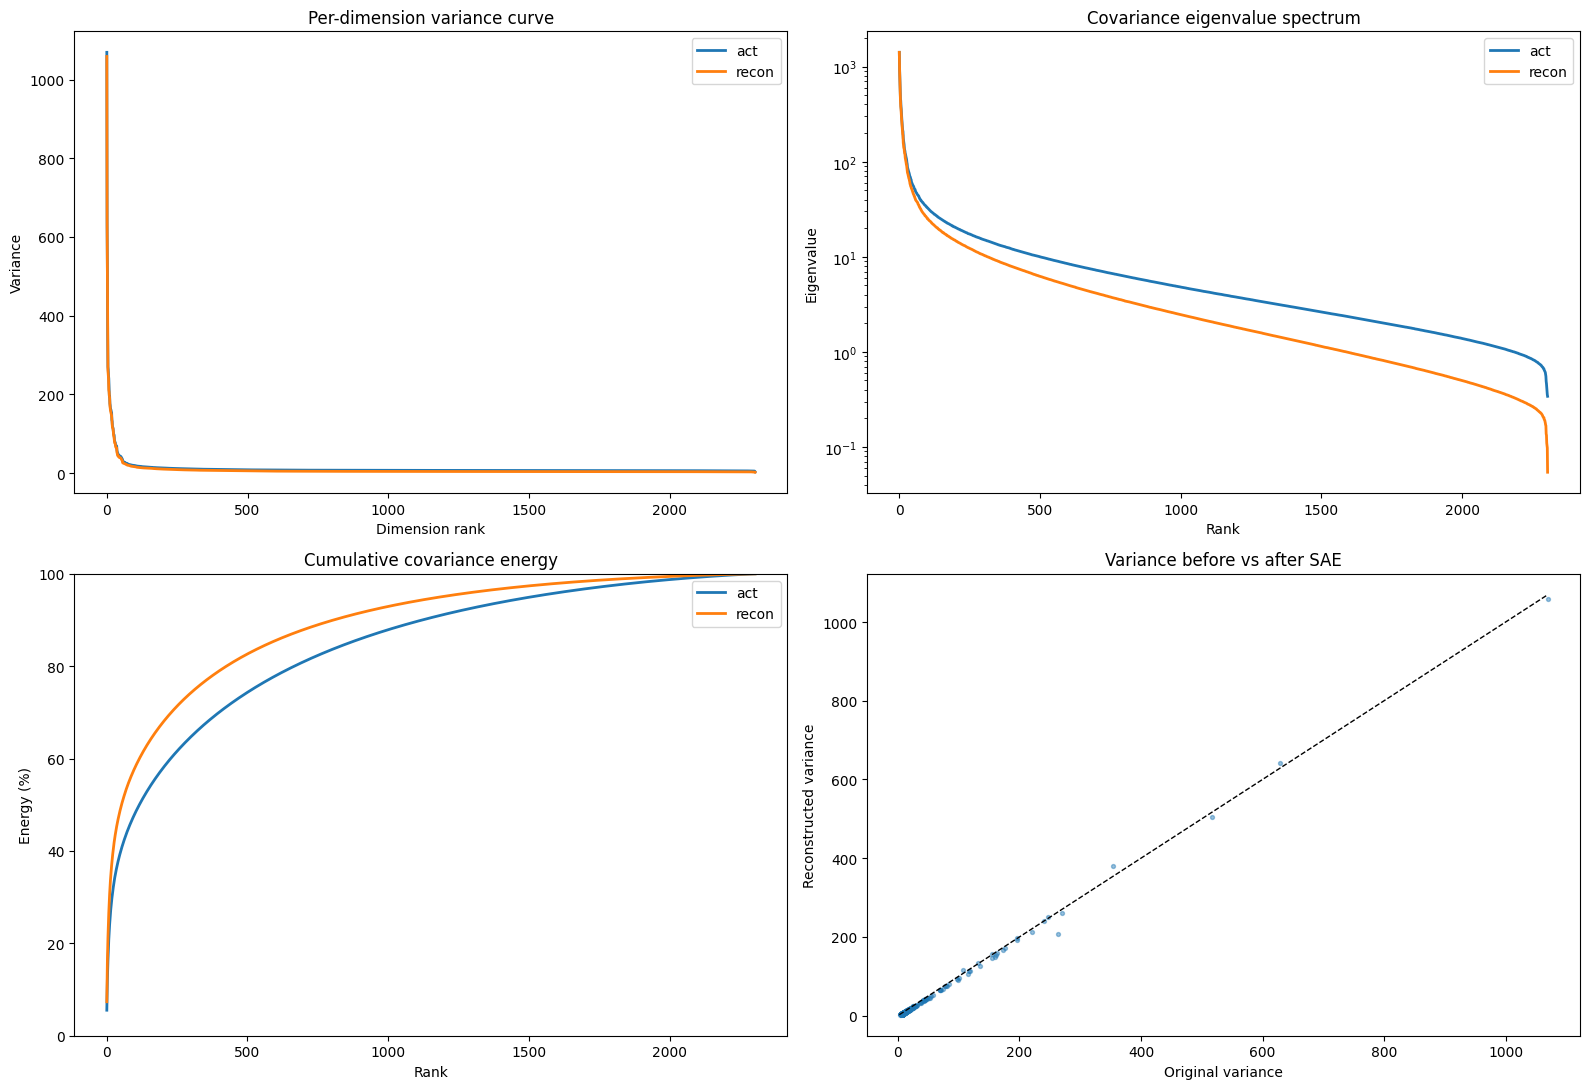

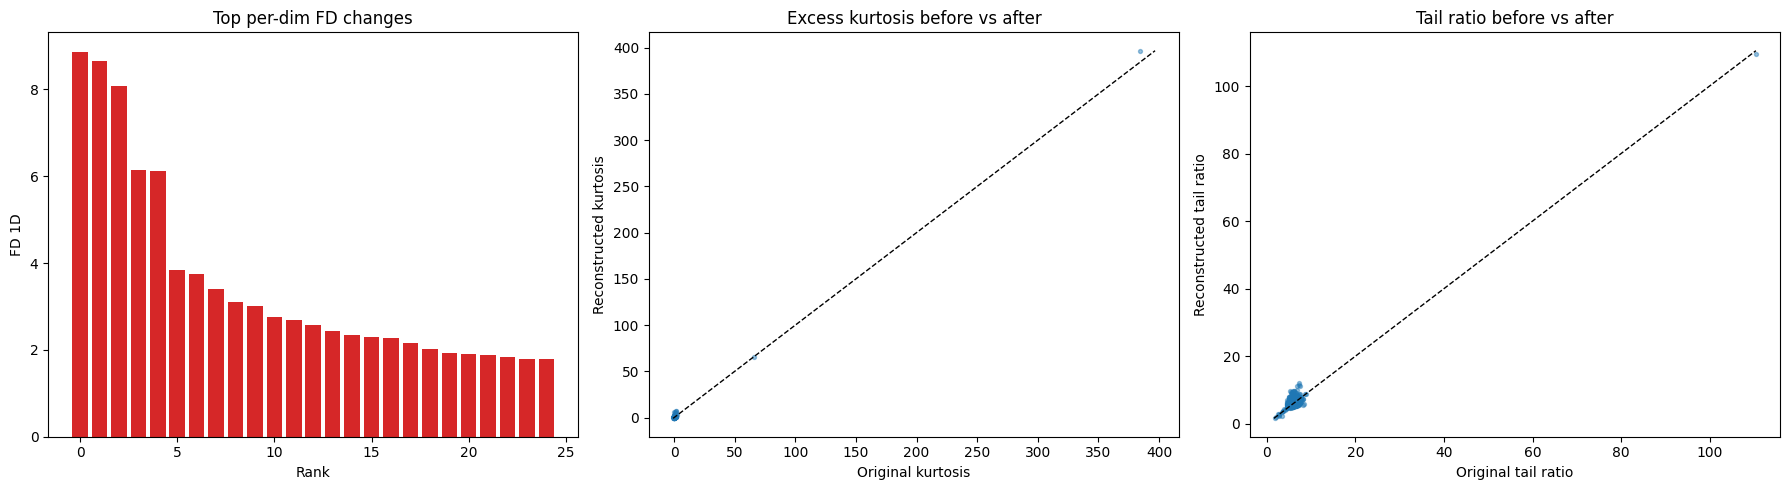

Saved summary to: /mnt/disk2/aiotlab/hoplt/Benchmark/Steering/post_process/sae_analysis_artifacts/sae_reconstruction_summary.json
Saved metrics to: /mnt/disk2/aiotlab/hoplt/Benchmark/Steering/post_process/sae_analysis_artifacts/sae_reconstruction_metrics.csv
Saved per-dim stats to: /mnt/disk2/aiotlab/hoplt/Benchmark/Steering/post_process/sae_analysis_artifacts/sae_reconstruction_dimension_stats.csv
Saved per-dim FD to: /mnt/disk2/aiotlab/hoplt/Benchmark/Steering/post_process/sae_analysis_artifacts/sae_reconstruction_fd_1d.csv
Saved covariance spectrum to: /mnt/disk2/aiotlab/hoplt/Benchmark/Steering/post_process/sae_analysis_artifacts/sae_reconstruction_cov_spectrum.csv
Saved plots to: /mnt/disk2/aiotlab/hoplt/Benchmark/Steering/post_process/sae_analysis_artifacts/figures/sae_reconstruction_distribution_diagnostics.png, /mnt/disk2/aiotlab/hoplt/Benchmark/Steering/post_process/sae_analysis_artifacts/figures/sae_reconstruction_tail_fd_diagnostics.png


In [7]:
spectrum_df = pd.DataFrame(
    {
        "rank": np.arange(1, len(act_eigvals) + 1),
        "act_cov_eig": act_eigvals,
        "recon_cov_eig": recon_eigvals,
        "act_cov_cum_energy_pct": 100.0 * np.cumsum(act_eigvals) / (act_eigvals.sum() + 1e-12),
        "recon_cov_cum_energy_pct": 100.0 * np.cumsum(recon_eigvals) / (recon_eigvals.sum() + 1e-12),
    }
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

act_var_sorted = np.sort(stats_df["act_var"].values)[::-1]
recon_var_sorted = np.sort(stats_df["recon_var"].values)[::-1]
axes[0, 0].plot(act_var_sorted, label="act", linewidth=2)
axes[0, 0].plot(recon_var_sorted, label="recon", linewidth=2)
axes[0, 0].set_title("Per-dimension variance curve")
axes[0, 0].set_xlabel("Dimension rank")
axes[0, 0].set_ylabel("Variance")
axes[0, 0].legend()

axes[0, 1].plot(spectrum_df["rank"], spectrum_df["act_cov_eig"], label="act", linewidth=2)
axes[0, 1].plot(spectrum_df["rank"], spectrum_df["recon_cov_eig"], label="recon", linewidth=2)
axes[0, 1].set_title("Covariance eigenvalue spectrum")
axes[0, 1].set_xlabel("Rank")
axes[0, 1].set_ylabel("Eigenvalue")
axes[0, 1].set_yscale("log")
axes[0, 1].legend()

axes[1, 0].plot(spectrum_df["rank"], spectrum_df["act_cov_cum_energy_pct"], label="act", linewidth=2)
axes[1, 0].plot(spectrum_df["rank"], spectrum_df["recon_cov_cum_energy_pct"], label="recon", linewidth=2)
axes[1, 0].set_title("Cumulative covariance energy")
axes[1, 0].set_xlabel("Rank")
axes[1, 0].set_ylabel("Energy (%)")
axes[1, 0].set_ylim(0, 100)
axes[1, 0].legend()

axes[1, 1].scatter(stats_df["act_var"], stats_df["recon_var"], s=8, alpha=0.45)
lo = min(stats_df["act_var"].min(), stats_df["recon_var"].min())
hi = max(stats_df["act_var"].max(), stats_df["recon_var"].max())
axes[1, 1].plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title("Variance before vs after SAE")
axes[1, 1].set_xlabel("Original variance")
axes[1, 1].set_ylabel("Reconstructed variance")

plt.tight_layout()
diagnostics_path = FIG_DIR / "sae_reconstruction_distribution_diagnostics.png"
fig.savefig(diagnostics_path, dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top_fd = fd_1d_df.head(25)
axes[0].bar(np.arange(len(top_fd)), top_fd["fd_1d"].values, color="tab:red")
axes[0].set_title("Top per-dim FD changes")
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("FD 1D")

axes[1].scatter(stats_df["act_excess_kurtosis"], stats_df["recon_excess_kurtosis"], s=8, alpha=0.45)
lo = min(stats_df["act_excess_kurtosis"].min(), stats_df["recon_excess_kurtosis"].min())
hi = max(stats_df["act_excess_kurtosis"].max(), stats_df["recon_excess_kurtosis"].max())
axes[1].plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1)
axes[1].set_title("Excess kurtosis before vs after")
axes[1].set_xlabel("Original kurtosis")
axes[1].set_ylabel("Reconstructed kurtosis")

axes[2].scatter(stats_df["act_tail_ratio"], stats_df["recon_tail_ratio"], s=8, alpha=0.45)
lo = min(stats_df["act_tail_ratio"].min(), stats_df["recon_tail_ratio"].min())
hi = max(stats_df["act_tail_ratio"].max(), stats_df["recon_tail_ratio"].max())
axes[2].plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1)
axes[2].set_title("Tail ratio before vs after")
axes[2].set_xlabel("Original tail ratio")
axes[2].set_ylabel("Reconstructed tail ratio")

plt.tight_layout()
tail_path = FIG_DIR / "sae_reconstruction_tail_fd_diagnostics.png"
fig.savefig(tail_path, dpi=180, bbox_inches="tight")
plt.show()

summary = {
    "config": CONFIG,
    "activation_cache_path": str(activation_cache_path),
    "reconstruction_cache_path": str(recon_cache_path),
    "metrics": metrics,
    "latent_summary": latent_summary.to_dict(orient="records")[0] if not latent_summary.empty else {},
    "act_global": act_global,
    "recon_global": recon_global,
    "diagnostics_plot": str(diagnostics_path),
    "tail_fd_plot": str(tail_path),
}

summary_path = OUTPUT_DIR / "sae_reconstruction_summary.json"
metrics_path = OUTPUT_DIR / "sae_reconstruction_metrics.csv"
stats_path = OUTPUT_DIR / "sae_reconstruction_dimension_stats.csv"
fd_1d_path = OUTPUT_DIR / "sae_reconstruction_fd_1d.csv"
spectrum_path = OUTPUT_DIR / "sae_reconstruction_cov_spectrum.csv"

with summary_path.open("w") as f:
    json.dump(summary, f, indent=2)
metrics_df.to_csv(metrics_path, index=False)
stats_df.to_csv(stats_path, index=False)
fd_1d_df.to_csv(fd_1d_path, index=False)
spectrum_df.to_csv(spectrum_path, index=False)

print(f"Saved summary to: {summary_path}")
print(f"Saved metrics to: {metrics_path}")
print(f"Saved per-dim stats to: {stats_path}")
print(f"Saved per-dim FD to: {fd_1d_path}")
print(f"Saved covariance spectrum to: {spectrum_path}")
print(f"Saved plots to: {diagnostics_path}, {tail_path}")
